In [1]:
import igraph as ig
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os

from Qommunity.samplers.regular.infomap_sampler import InfomapSampler
from Qommunity.samplers.regular.sbm_sampler import SBMSampler
from Qommunity.samplers.regular.spectral_sampler import SpectralSampler
from Qommunity.samplers.regular.louvain_sampler import LouvainSampler
from Qommunity.samplers.regular.leiden_sampler import LeidenSampler
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler

from Qommunity.iterative_searcher import IterativeSearcher

type_net = 'Connected' #'Nested'#
NUM_NETWORKS = 10
resolution = 1
num_runs_classical = 100
num_runs_SBM_NMI = 50

os.makedirs(f"./SBMs/{type_net}/", exist_ok=True)

In [2]:
def get_communities(state):
    node_assignment = np.array(state.get_blocks().a)
    communities = []
    for c in np.unique(node_assignment):
        communities.append({i for i,n in enumerate(node_assignment) if n==c})

    return communities

def get_communities_ground_truth(blocks):
    communities = []
    for c in np.unique(blocks):
        communities.append({i for i,n in enumerate(blocks) if n==c})

    return communities

def get_assignments(G, communities_nx):
    node2comm = {}
    for cid, comm in enumerate(communities_nx):
        for node in comm:
            node2comm[node] = cid
    return [node2comm[n] for n in G.nodes()]

def SBM_nx(sizes, P_planted, deg=None, lambd=0.8, beta=.1):
    blocks = []
    for i, size in enumerate(sizes):
        blocks += [i] * size
    blocks = np.array(blocks)
    
    P_rand = np.random.random(P_planted.shape)
    P_rand =  0.5 * (P_rand + P_rand.T) * beta
    P = lambd * P_planted + (1-lambd) * P_rand

    G = nx.stochastic_block_model(sizes, P)

    return G, blocks

def connected_SBM(groups, p):
    """
    Generate a planted SBM probability matrix P_planted 
    for arbitrary number of communities.

    method: "random" or something else
    groups  : list of community sizes
    p      : within-block probability
    """
    
    K = len(groups)
    P_planted = np.zeros((K, K))

    # Set off-diagonal entries all equal
    off_diag_val = (1 - p) / (K - 1)
    for i in range(K):
        for j in range(K):
            if i == j:
                P_planted[i, i] = p
            else:
                P_planted[i, j] = off_diag_val

    return P_planted


def nested_SBM(groups, kappas):
    """
    Build a hierarchical SBM probability matrix P for arbitrary number
    of groups and hierarchy depth.

    Parameters
    ----------
    groups : list or array-like of int
        Group labels for each block (length K).
        Labels must go from 0...(K-1).
    
    kappas : list or array of float
        Hierarchical levels: kappa[0] > kappa[1] > ... > kappa[L-1].
        Typically kappa[0] is the within-block probability, and deeper 
        levels describe shared ancestry in the hierarchy.

    Returns
    -------
    P : np.ndarray, shape (K, K)
        Block probability matrix.
    """
    groups = np.array(groups)
    K = len(groups)
    kappas = kappas + [0] # For convenience

    P = np.zeros((K, K), dtype=float)
    for i in range(K):
        for j in range(i,K):
            if i == j:
                # subtract next-level probability like your example
                P[i, j] = kappas[i] - kappas[i+1]
            else:
                P[i, j] = kappas[j]
                P[j, i] = kappas[j]
    
    return P

def get_array(mixing, probabilities, *args):
    metric_values = []
    for values in args:
        values = values[()]
        metric_values.append(
            np.array([[values[f'Lambda: {l.round(2)} and Prob: {p.round(2)}'] for l in mixing] for p in probabilities]).T
        )    
    return metric_values

In [3]:
# SBM generative parameters
lambdas = np.arange(0,1,0.1)
ps = np.arange(0.6,1,0.1)
gamma = 1
alpha = 10
beta = 0.6
sizes = [50, 40, 10]
sizes_str = ""
for s in sizes:
    sizes_str += "-" + str(s)

os.makedirs(f"./SBMs/{type_net}/Networks/", exist_ok=True)

Graphs = {}
Blocks = {}
for i, l in enumerate(lambdas):
    for j, p in enumerate(ps):
            try:
                Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = np.load(f"./SBMs/{type_net}/Networks/Graphs-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}.npy", allow_pickle=True)
                Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = np.load(f"./SBMs/{type_net}/Networks/Blocks-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}.npy", allow_pickle=True)
            except:
                Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = np.empty(shape=(NUM_NETWORKS,), dtype=object)
                Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = np.empty(shape=(NUM_NETWORKS,), dtype=object)

                for net in range(NUM_NETWORKS):                 
                    if type_net=='Connected':
                        P_planted = connected_SBM(sizes, p)
                    elif type_net=='Nested':
                        P_planted = nested_SBM(sizes, [p/(alpha**i) for i in range(len(sizes))])
                    else:
                        print("Wrong type of SBM selected")
                    
                    Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"][net], Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"][net] = SBM_nx(sizes, P_planted, lambd=l, beta=beta)

                np.save(f"./SBMs/{type_net}/Networks/Graphs-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}.npy", Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"])  
                np.save(f"./SBMs/{type_net}/Networks/Blocks-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}.npy", Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"])   

                print(f"Stochastic block models (SBMs) created and saved for: Graphs-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}")

In [4]:
### LOUVAIN
try:
    louv_vi = np.load(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_vi.npy", allow_pickle=True)
    louv_splitjoint = np.load(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_splitjoint.npy", allow_pickle=True)
    louv_nmi = np.load(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_ni.npy", allow_pickle=True)
    louv_adjusted_rand = np.load(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_adjusted_rand.npy", allow_pickle=True)
    louv_modularities = np.load(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_modularities.npy", allow_pickle=True)
    print("Reasults loaded")
except:
    louv_vi = {}
    louv_splitjoint = {}
    louv_nmi = {}
    louv_adjusted_rand = {}
    louv_modularities = {}

    for i, l in enumerate(lambdas):
        for j, p in enumerate(ps):
            louv_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            louv_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            louv_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            louv_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            louv_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0

            for G, B in zip(Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"], Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"]):
                louv_sampler = LouvainSampler(G, resolution=resolution)
                louv_iterative = IterativeSearcher(louv_sampler)
                cs_all, mod_all, ts_all = louv_iterative.run(num_runs=num_runs_classical, save_results=False)
                louv_communities = cs_all[mod_all.argmax()]
                louv_assignments = get_assignments(G, louv_communities)

                # Only the community with the highest modularity
                louv_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += mod_all.max() / NUM_NETWORKS
                louv_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, louv_assignments, method='vi') / NUM_NETWORKS
                louv_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, louv_assignments, method='split-join') / NUM_NETWORKS
                louv_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, louv_assignments, method='nmi') / NUM_NETWORKS
                louv_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, louv_assignments, method='adjusted_rand') / NUM_NETWORKS

    louv_vi = np.save(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_vi.npy", louv_vi, allow_pickle=True)
    louv_splitjoint = np.save(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_splitjoint.npy", louv_splitjoint, allow_pickle=True)
    louv_nmi = np.save(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_ni.npy", louv_nmi, allow_pickle=True)
    louv_adjusted_rand = np.save(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_adjusted_rand.npy", louv_adjusted_rand, allow_pickle=True)
    louv_modularities = np.save(f"./SBMs/{type_net}/solver-louv_runs-{num_runs_classical}_modularities.npy", louv_modularities, allow_pickle=True)

Reasults loaded


In [5]:
### LEIDEN
try:
    leid_vi = np.load(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_vi.npy", allow_pickle=True)
    leid_splitjoint = np.load(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_splitjoint.npy", allow_pickle=True)
    leid_nmi = np.load(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_ni.npy", allow_pickle=True)
    leid_adjusted_rand = np.load(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_adjusted_rand.npy", allow_pickle=True)
    leid_modularities = np.load(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_modularities.npy", allow_pickle=True)
    print("Reasults loaded")
except:
    leid_vi = {}
    leid_splitjoint = {}
    leid_nmi = {}
    leid_adjusted_rand = {}
    leid_modularities = {}

    for i, l in enumerate(lambdas):
        for j, p in enumerate(ps):
            leid_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            leid_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            leid_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            leid_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            leid_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0

            for G, B in zip(Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"], Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"]):
                leid_sampler = LeidenSampler(G, resolution=resolution)
                leid_iterative = IterativeSearcher(leid_sampler)
                cs_all, mod_all, ts_all = leid_iterative.run(num_runs=1, save_results=False)
                leid_communities = cs_all[mod_all.argmax()]
                leid_assignments = get_assignments(G, leid_communities)

                # Only the community with the highest modularity
                leid_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += mod_all.max() / NUM_NETWORKS
                leid_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, leid_assignments, method='vi') / NUM_NETWORKS
                leid_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, leid_assignments, method='split-join') / NUM_NETWORKS
                leid_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, leid_assignments, method='nmi') / NUM_NETWORKS
                leid_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, leid_assignments, method='adjusted_rand') / NUM_NETWORKS

    leid_vi = np.save(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_vi.npy", leid_vi, allow_pickle=True)
    leid_splitjoint = np.save(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_splitjoint.npy", leid_splitjoint, allow_pickle=True)
    leid_nmi = np.save(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_ni.npy", leid_nmi, allow_pickle=True)
    leid_adjusted_rand = np.save(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_adjusted_rand.npy", leid_adjusted_rand, allow_pickle=True)
    leid_modularities = np.save(f"./SBMs/{type_net}/solver-leid_runs-{num_runs_classical}_modularities.npy", leid_modularities, allow_pickle=True)

Reasults loaded


In [6]:
### SBM
try:
    sbm_vi = np.load(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_vi.npy", allow_pickle=True)
    sbm_splitjoint = np.load(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_splitjoint.npy", allow_pickle=True)
    sbm_nmi = np.load(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_ni.npy", allow_pickle=True)
    sbm_adjusted_rand = np.load(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_adjusted_rand.npy", allow_pickle=True)
    sbm_modularities = np.load(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_modularities.npy", allow_pickle=True)
    print("Reasults loaded")
except:
    sbm_vi = {}
    sbm_splitjoint = {}
    sbm_nmi = {}
    sbm_adjusted_rand = {}
    sbm_modularities = {}

    for i, l in enumerate(lambdas):
        for j, p in enumerate(ps):
            sbm_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            sbm_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            sbm_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            sbm_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            sbm_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0

            for G, B in zip(Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"], Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"]):
                max_nmi = -1
                for nmi_run in range(num_runs_SBM_NMI):
                    sbm_sampler = SBMSampler(G, epropweight=False)
                    sbm_iterative= IterativeSearcher(sbm_sampler)
                    cs_sbm, _, _ = sbm_iterative.run(num_runs=1, save_results=False)
                    cs_sbm = cs_sbm[0]
                    a_sbm = get_assignments(G, cs_sbm)
                    r_nmi = ig.clustering.compare_communities(B, a_sbm, method='nmi')

                    if r_nmi>=max_nmi:
                        max_nmi = r_nmi
                        sbm_assignments = a_sbm
                        sbm_communities = cs_sbm
                        
                # Only the community with the highest modularity
                sbm_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += nx.community.modularity(G, sbm_communities, resolution=resolution) / NUM_NETWORKS
                sbm_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, sbm_assignments, method='vi') / NUM_NETWORKS
                sbm_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, sbm_assignments, method='split-join') / NUM_NETWORKS
                sbm_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, sbm_assignments, method='nmi') / NUM_NETWORKS
                sbm_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, sbm_assignments, method='adjusted_rand') / NUM_NETWORKS

    sbm_vi = np.save(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_vi.npy", sbm_vi, allow_pickle=True)
    sbm_splitjoint = np.save(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_splitjoint.npy", sbm_splitjoint, allow_pickle=True)
    sbm_nmi = np.save(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_ni.npy", sbm_nmi, allow_pickle=True)
    sbm_adjusted_rand = np.save(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_adjusted_rand.npy", sbm_adjusted_rand, allow_pickle=True)
    sbm_modularities = np.save(f"./SBMs/{type_net}/solver-sbm_runs-{num_runs_SBM_NMI}_modularities.npy", sbm_modularities, allow_pickle=True)


Reasults loaded


In [7]:
### INFOMAP
try:
    info_vi = np.load(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_vi.npy", allow_pickle=True)
    info_splitjoint = np.load(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_splitjoint.npy", allow_pickle=True)
    info_nmi = np.load(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_ni.npy", allow_pickle=True)
    info_adjusted_rand = np.load(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_adjusted_rand.npy", allow_pickle=True)
    info_modularities = np.load(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_modularities.npy", allow_pickle=True)
    print("Reasults loaded")
except:
    info_vi = {}
    info_splitjoint = {}
    info_nmi = {}
    info_adjusted_rand = {}
    info_modularities = {}

    for i, l in enumerate(lambdas):
        for j, p in enumerate(ps):
            info_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            info_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            info_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            info_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            info_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0

            for G, B in zip(Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"], Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"]):
                max_nmi = -1
                for nmi_run in range(num_runs_SBM_NMI):
                    info_sampler = InfomapSampler(G)
                    info_iterative= IterativeSearcher(info_sampler)
                    cs_info, _, _ = info_iterative.run(num_runs=1, save_results=False)
                    cs_info = cs_info[0]
                    a_info = get_assignments(G, cs_info)
                    r_nmi = ig.clustering.compare_communities(B, a_info, method='nmi')

                    if r_nmi>=max_nmi:
                        max_nmi = r_nmi
                        info_assignments = a_info
                        info_communities = cs_info
                        
                # Only the community with the highest modularity
                info_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += nx.community.modularity(G, info_communities, resolution=resolution) / NUM_NETWORKS
                info_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, info_assignments, method='vi') / NUM_NETWORKS
                info_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, info_assignments, method='split-join') / NUM_NETWORKS
                info_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, info_assignments, method='nmi') / NUM_NETWORKS
                info_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, info_assignments, method='adjusted_rand') / NUM_NETWORKS

    info_vi = np.save(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_vi.npy", info_vi, allow_pickle=True)
    info_splitjoint = np.save(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_splitjoint.npy", info_splitjoint, allow_pickle=True)
    info_nmi = np.save(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_ni.npy", info_nmi, allow_pickle=True)
    info_adjusted_rand = np.save(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_adjusted_rand.npy", info_adjusted_rand, allow_pickle=True)
    info_modularities = np.save(f"./SBMs/{type_net}/solver-info_runs-{num_runs_SBM_NMI}_modularities.npy", info_modularities, allow_pickle=True)

Reasults loaded


In [8]:
### SPECTRAL CLUSTERING
try:
    spec_vi = np.load(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_vi.npy", allow_pickle=True)
    spec_splitjoint = np.load(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_splitjoint.npy", allow_pickle=True)
    spec_nmi = np.load(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_ni.npy", allow_pickle=True)
    spec_adjusted_rand = np.load(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_adjusted_rand.npy", allow_pickle=True)
    spec_modularities = np.load(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_modularities.npy", allow_pickle=True)
    print("Reasults loaded")
except:
    spec_vi = {}
    spec_splitjoint = {}
    spec_nmi = {}
    spec_adjusted_rand = {}
    spec_modularities = {}

    for i, l in enumerate(lambdas):
        for j, p in enumerate(ps):
            spec_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            spec_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            spec_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            spec_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0
            spec_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] = 0

            for G, B in zip(Graphs[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"], Blocks[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"]):
                spec_sampler = SpectralSampler(G)
                spec_iterative = IterativeSearcher(spec_sampler)
                cs_all, mod_all, ts_all = spec_iterative.run(num_runs=1, save_results=False)
                spec_communities = cs_all[mod_all.argmax()]
                spec_assignments = get_assignments(G, spec_communities)

                # Only the community with the highest modularity
                spec_modularities[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += mod_all.max() / NUM_NETWORKS
                spec_vi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, spec_assignments, method='vi') / NUM_NETWORKS
                spec_splitjoint[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, spec_assignments, method='split-join') / NUM_NETWORKS
                spec_nmi[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, spec_assignments, method='nmi') / NUM_NETWORKS
                spec_adjusted_rand[f"Lambda: {round(l,2)} and Prob: {round(p,2)}"] += ig.clustering.compare_communities(B, spec_assignments, method='adjusted_rand') / NUM_NETWORKS

    spec_vi = np.save(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_vi.npy", spec_vi, allow_pickle=True)
    spec_splitjoint = np.save(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_splitjoint.npy", spec_splitjoint, allow_pickle=True)
    spec_nmi = np.save(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_ni.npy", spec_nmi, allow_pickle=True)
    spec_adjusted_rand = np.save(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_adjusted_rand.npy", spec_adjusted_rand, allow_pickle=True)
    spec_modularities = np.save(f"./SBMs/{type_net}/solver-spec_runs-{num_runs_classical}_modularities.npy", spec_modularities, allow_pickle=True)

Reasults loaded


In [9]:
metrics_louvain = get_array(lambdas, ps, louv_vi, louv_splitjoint, louv_nmi, louv_adjusted_rand, louv_modularities)
metrics_leiden = get_array(lambdas, ps, leid_vi, leid_splitjoint, leid_nmi, leid_adjusted_rand, leid_modularities)
metrics_sbminference = get_array(lambdas, ps, sbm_vi, sbm_splitjoint, sbm_nmi, sbm_adjusted_rand, sbm_modularities)
metrics_infomap = get_array(lambdas, ps, info_vi, info_splitjoint, info_nmi, info_adjusted_rand, info_modularities)
metrics_spectral = get_array(lambdas, ps, spec_vi, spec_splitjoint, spec_nmi, spec_adjusted_rand, spec_modularities)

ylabels = ["Variation of information (VI)", "Split-join distance", "Normalized mutual information (NMI)", "Adjusted Rand index", "Modularity (Q)"]

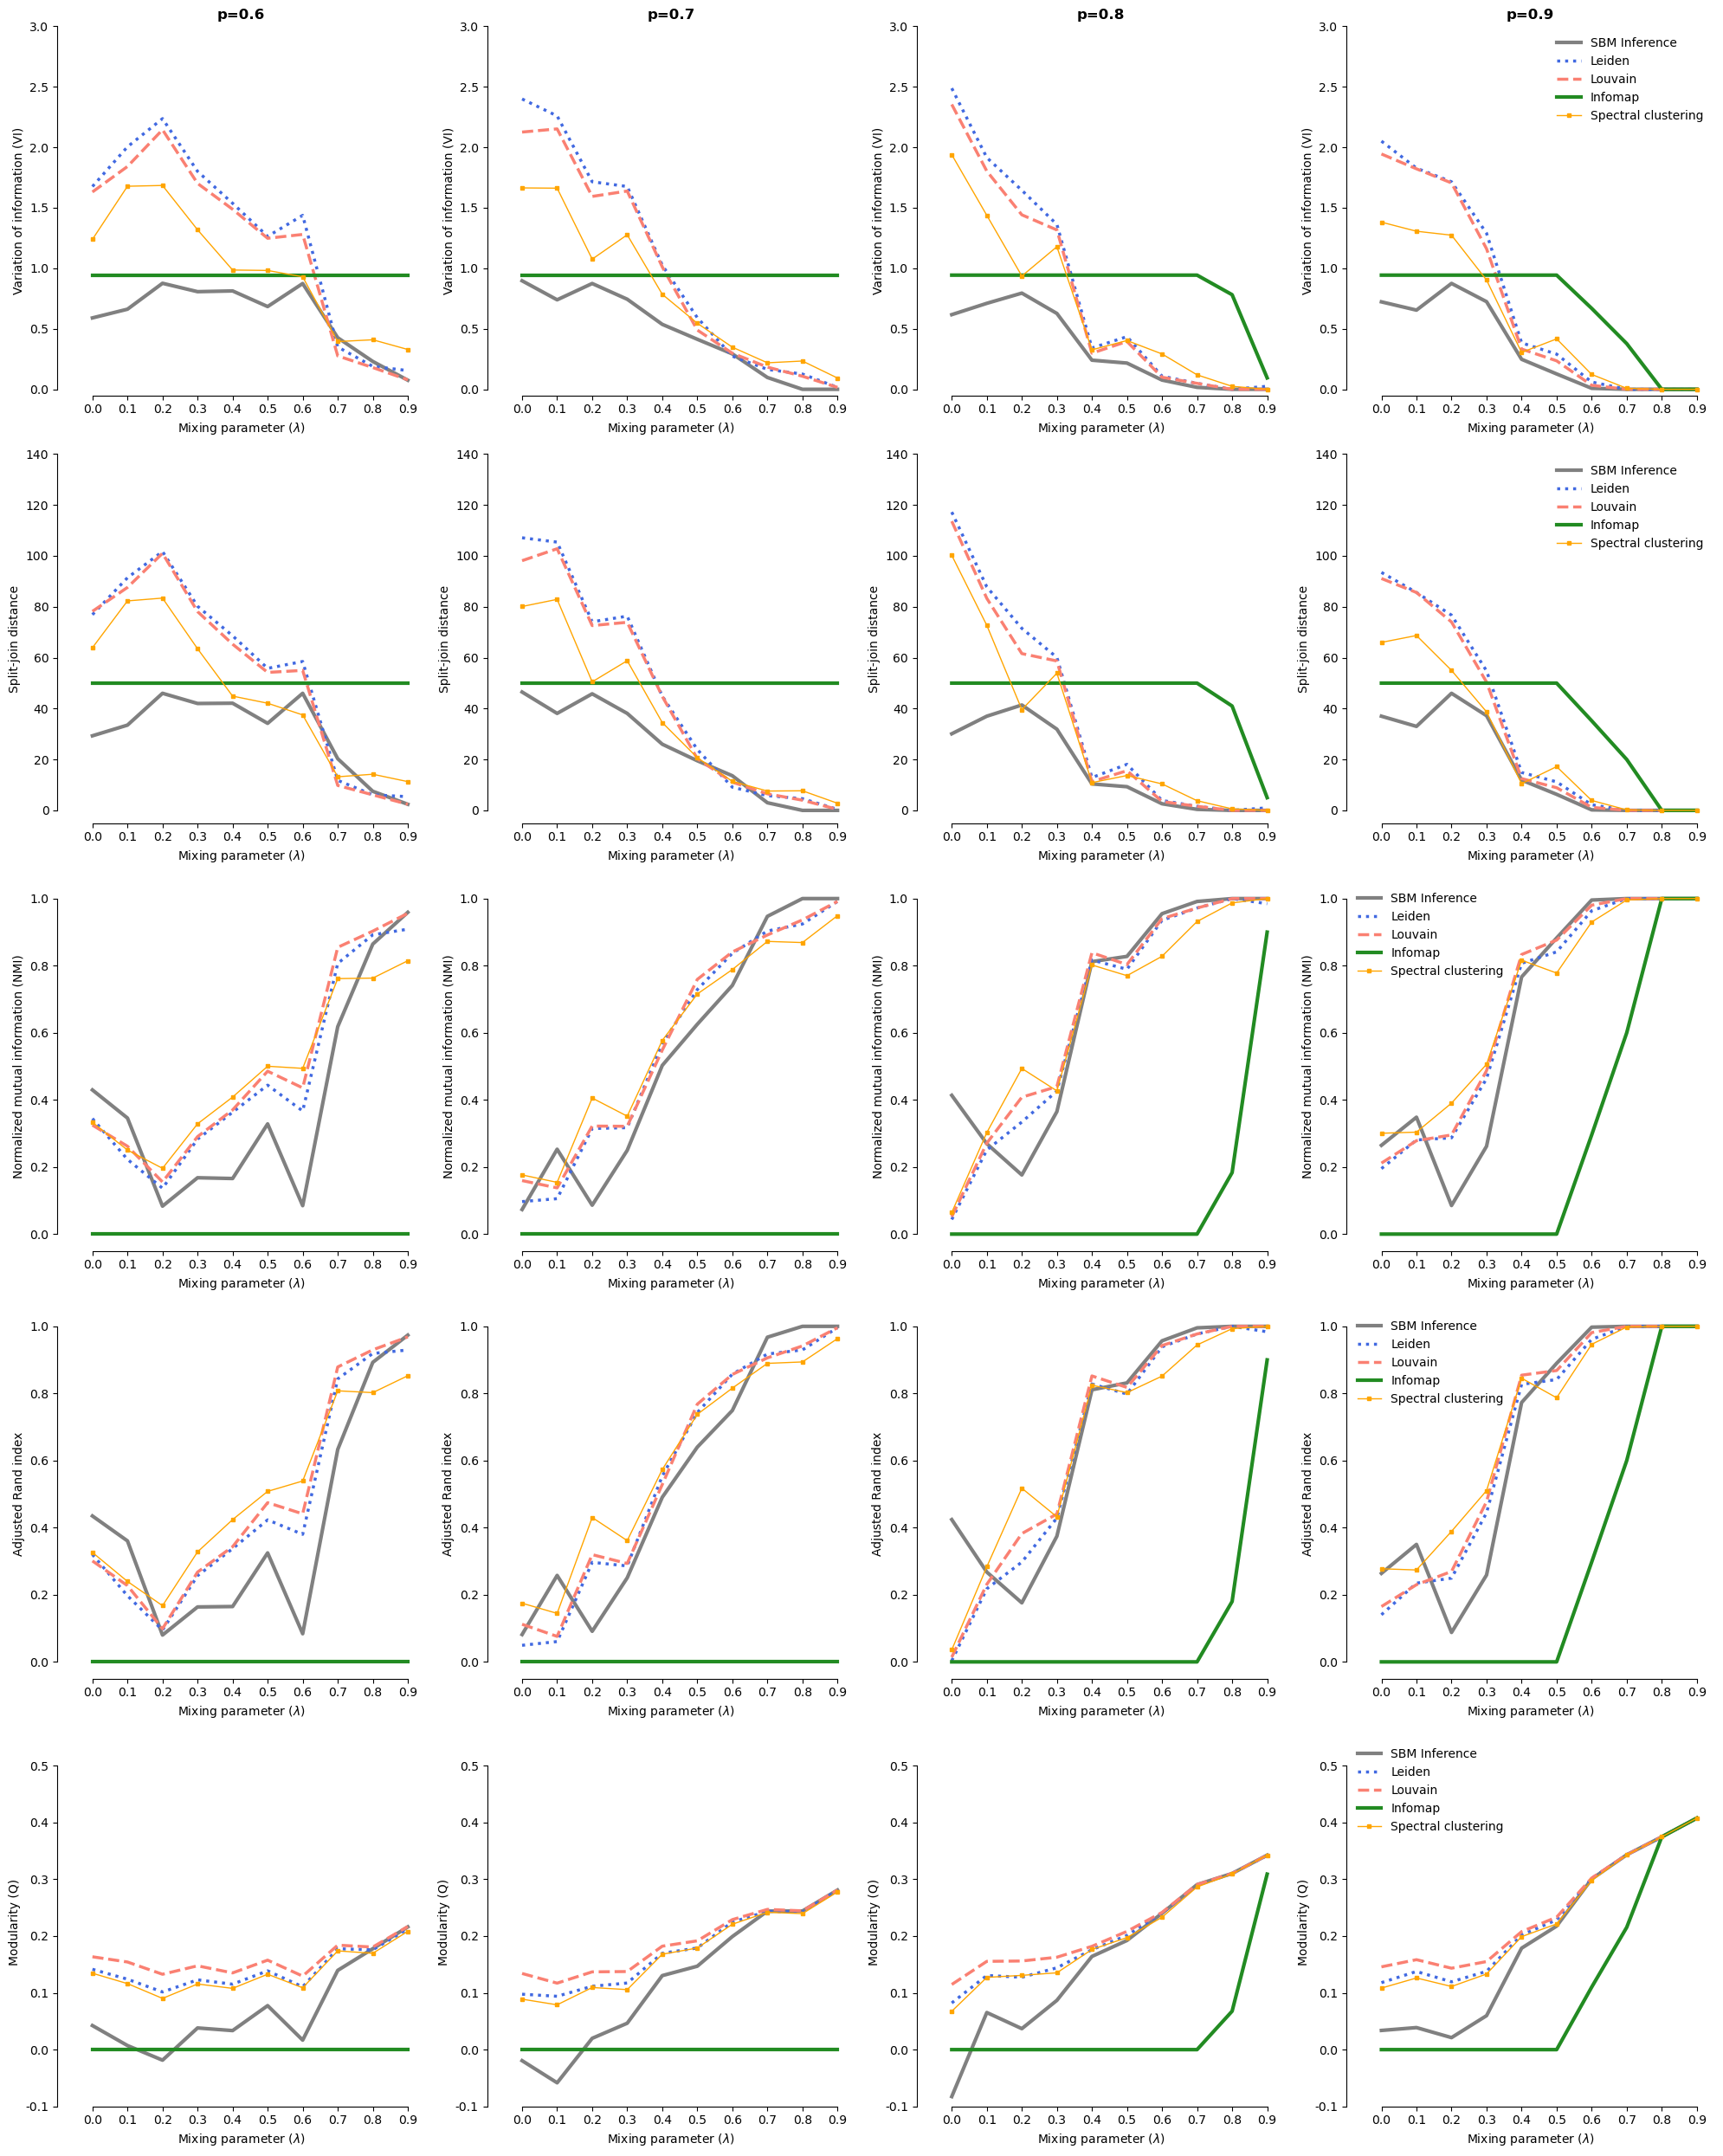

In [10]:
fig, ax = plt.subplots(len(ylabels), len(ps),figsize=(5 * len(ps), len(ylabels) * 5))

for i in range(len(ylabels)):
    for j in range(len(ps)):
        ax[i, j].plot(lambdas, metrics_sbminference[i][:,j],"-",label="SBM Inference",linewidth=3,color="gray")
        ax[i, j].plot(lambdas, metrics_leiden[i][:,j], label="Leiden", linewidth=2.5, color="royalblue", linestyle="dotted")
        ax[i, j].plot(lambdas, metrics_louvain[i][:,j],"--",label="Louvain",linewidth=2.5,color="salmon")
        ax[i, j].plot(lambdas, metrics_infomap[i][:,j],"-",label="Infomap",linewidth=3,color="forestgreen")
        ax[i, j].plot(lambdas, metrics_spectral[i][:,j],"-s",label="Spectral clustering",linewidth=1,color="orange", markersize=3)

        ax[i, j].spines[["top", "right"]].set_visible(False)
        if (i==2) or (i==3):
            ax[i, j].set_ylim([-.05,1.05])
            ax[i, j].set_yticks(np.arange(0,1.2,.2))
            ax[i, j].set_yticklabels(np.arange(0,1.2,.2).round(1))
            ax[i, j].spines['left'].set_bounds(0, 1)    
        elif i==0:
            ax[i, j].set_ylim([-.05,3])
            ax[i, j].set_yticks(np.arange(0,3.1,.5))
            ax[i, j].set_yticklabels(np.arange(0,3.1,.5).round(1))
            ax[i, j].spines['left'].set_bounds(0, 3)    
        elif i==1:
            ax[i, j].set_ylim([-5,140])
            ax[i, j].set_yticks(np.arange(0,145,20))
            ax[i, j].set_yticklabels(np.arange(0,145,20))
            ax[i, j].spines['left'].set_bounds(0, 140)  
        elif i==4:
            ax[i, j].set_ylim([-.1,.55])
            ax[i, j].set_yticks(np.arange(-0.1,.55,.1))
            ax[i, j].set_yticklabels(np.arange(-.1, .55,.1).round(2))
            ax[i, j].spines['left'].set_bounds(-.1, .5)  

        ax[i, j].set_ylabel(ylabels[i])   

        if j==(len(ps)-1):
            ax[i, j].legend(frameon=False)

        if i==0:
            ax[i, j].set_title(f"p={ps[j].round(2)}", fontweight="bold")
        
        ax[i,j].set_xlim([lambdas[0]-.1, lambdas[-1]+.05])
        ax[i,j].set_xticks(lambdas.round(2))
        ax[i,j].spines['bottom'].set_bounds(lambdas[0], lambdas[-1])
        ax[i, j].set_xlabel("Mixing parameter ("+r'$\lambda$'+")")

fig.tight_layout()
fig.savefig(f"./SBMs/{type_net}/Recovery-Blocks_Metrics-Methods.svg", dpi=200, format= "svg")

In [11]:
os.makedirs(f"./SBMs/{type_net}/Networks/Plots/", exist_ok=True)

for k in Graphs.keys():
    i = np.random.randint(0, NUM_NETWORKS)
    GGG = Graphs['Lambda: 0.9 and Prob: 0.9'][i]
    BBB = Blocks['Lambda: 0.9 and Prob: 0.9'][i]

    l = float(k.split(" ")[1])
    p = float(k.split(" ")[-1])

    if not os.path.exists(f"./SBMs/{type_net}/Networks/Plots/Graphs-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}.svg"):
        fig, ax = plt.subplots(1, 1, figsize=(5,4))
        nx.draw_networkx(
            GGG, 
            node_color=BBB, 
            ax=ax, with_labels=False, 
            edge_color="black", 
            width=0.1, 
            node_size=50, 
            alpha=.6
        )
        ax.spines[["top","bottom","right","left"]].set_visible(False)

        ax.set_title(k, fontweight="bold")
        fig.tight_layout()
        fig.savefig(f"./SBMs/{type_net}/Networks/Plots/Graphs-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}.svg", dpi=150, format= "svg")
        plt.close()
    else:
        print(f"Already exists: Graphs-{type_net}_sizes{sizes_str}_lambda-{round(l,2)}_prob-{round(p,2)}.svg")